# **Quadratic Equation Workflow**

In [34]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
# create state
class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [27]:
def show_equation(state: QuadState):

    equation = f'{state["a"]}x^2 {state["b"]:+}x {state["c"]:+}'

    return {'equation':equation}

def calculate_discriminant(state: QuadState):

    discriminant = state["b"]**2 - (4*state["a"]*state["c"])

    return {'discriminant': discriminant}

In [33]:
def real_roots(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}


def no_real_roots(state: QuadState):

    result = f'No real roots'

    return {'result': result}

In [41]:
# For conditional workflow
# Return node based on condition
def check_condition(state: QuadState) -> Literal['real_roots', 'repeated_roots', 'no_real_roots']:
    
    if state['discriminant'] > 0:
        return 'real_roots'
    
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    
    else:
        return 'no_real_roots'

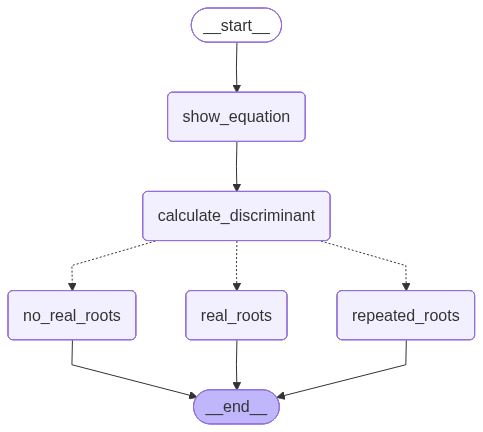

In [42]:

graph = StateGraph(QuadState)

# Nodes
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

# conditional edge
graph.add_conditional_edges('calculate_discriminant', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()
workflow

In [43]:
initial_state = {
    'a': 5,
    'b': 6,
    'c': -2
}

final_state = workflow.invoke(initial_state)

In [45]:
final_state

{'a': 5,
 'b': 6,
 'c': -2,
 'equation': '5x^2 +6x -2',
 'discriminant': 76,
 'result': 'The roots are 0.2717797887081348 and -1.4717797887081348'}

# **LLM Based Contional Workflow**

In [1]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import TypedDict, Literal


In [37]:
class FlowState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [3]:
load_dotenv()

model = ChatOpenAI(model='gpt-4o-mini')

In [30]:
class SentimentStructure(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description='Give the sentiment of the review')

sentiment_model = model.with_structured_output(SentimentStructure)

In [38]:
def sentiment_analysis(state: FlowState):
    review = state['review']

    prompt = f"Find the sentiment for the following review \n {review}"

    output = sentiment_model.invoke(prompt)

    return {'sentiment': output.sentiment}


In [55]:
def positive_response(state: FlowState):
    prompt = f"""
    Write a warm thank-you message in response to this review: \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website.

"""
    response = model.invoke(prompt).content
    return {'response': response}

def negative_response(state: FlowState):
    diagnosis = state['diagnosis']
    prompt = f"""
    You are a support assistant
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content
    return {'response': response}

In [46]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

diagnosis_model = model.with_structured_output(DiagnosisSchema)

def run_diagnosis(state: FlowState):
    prompt = f"""
    Diagnose this negative review:\n\n{state['review']}
    \n\nReturn issue_type, tone, and urgency.
"""
    output = diagnosis_model.invoke(prompt)

    return {'diagnosis': {'issue_type': output.issue_type, 'tone': output.tone, 'urgency': output.urgency}}


In [56]:
def check_sentiment(state: FlowState) -> Literal["positive_response", "run_diagnosis"]:
    if(state["sentiment"] == 'positive'):
        return "positive_response"
    else:
        return "run_diagnosis"

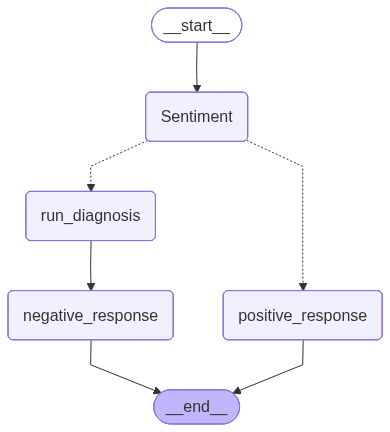

In [57]:
graph = StateGraph(FlowState)

graph.add_node('Sentiment', sentiment_analysis)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'Sentiment')

# condition edge
graph.add_conditional_edges('Sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()
workflow

In [65]:
initial_state_neg={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

final_state = workflow.invoke(initial_state_neg)

In [66]:
final_state

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help with Your Bug Issue\n\nHi [User's Name],\n\nI truly understand how frustrating it can be to deal with bugs, especially when it impacts your work. I appreciate you reaching out to us with urgency, and I want to assure you that we’re here to help resolve this as quickly as possible.\n\nTo better assist you, could you please provide a bit more detail about the issue you’re facing? Specifically, the steps that led to the bug, any error messages you received, and the device or platform you’re using would be incredibly helpful. \n\nOnce I have that information, I’ll prioritize your case and work with our tec